![QuantConnect Logo](https://cdn.quantconnect.com/web/i/icon.png)
<hr>

## Quiver Government Contracts Research

This notebook studies whether government contract dollar volume helps explain next future returns.

In [1]:
qb = QuantBook()
# Daily bars will have an end_time that matches the following midnight.
qb.settings.daily_precise_end_time = False

### Build a Government Contract Universe

Select assets with frequent, sizable US government contracts, then inspect the returned universe history.

In [2]:
def select_assets(data: List[QuiverGovernmentContractUniverse]) -> List[Symbol]:
    # Group by ticker and keep names with 3+ contracts totalling over $50K.
    contracts_by_symbol: dict[Symbol, list[QuiverGovernmentContractUniverse]] = {}
    for d in data:
        contracts_by_symbol.setdefault(d.symbol, []).append(d)
    return [s for s, ds in contracts_by_symbol.items()
            if len(ds) >= 3 and sum(x.amount or 0 for x in ds) > 50_000]

# Add the Quiver Government Contract universe.
universe = qb.add_universe(QuiverGovernmentContractUniverse, select_assets)
# Request recent universe history.
universe_history = qb.universe_history(universe, qb.time - timedelta(252), qb.time - timedelta(1), flatten=True)
# Print the returned shape and columns.
print(f"Shape: {universe_history.shape}")
print(f"Columns: {list(universe_history.columns)}")
universe_history.head()

Shape: (1307, 5)
Columns: ['agency', 'amount', 'description', 'value', 'time']


agency  \
time                                                                   
2025-09-23 A RPTMYV3VC57P    Department of Health and Human Services   
           CDW VHRARJ4RLSV9             Department of Transportation   
           EW RTKJ7O7ZTI79            Department of Veterans Affairs   
           F R735QTJ8XC9X            General Services Administration   
           MCK R735QTJ8XC9X           Department of Veterans Affairs   

                                amount  \
time                                     
2025-09-23 A RPTMYV3VC57P    291469.05   
           CDW VHRARJ4RLSV9  191949.00   
           EW RTKJ7O7ZTI79    11000.00   
           F R735QTJ8XC9X     32976.00   
           MCK R735QTJ8XC9X   11859.00   

                                                                   description  \
time                                                                             
2025-09-23 A RPTMYV3VC57P    AGILENT 1290 INFINITY III LC WITH 6475 TRIPLE ...   
           CDW VHRARJ4RLSV9      ELASTIC SEARCH SOFTWARE 12-MONTH SUBSCRIPTION   
           EW RTKJ7O7ZTI79                                             IMPLANT   
           F R735QTJ8XC9X    4X2 PICKUP; MID-SIZE; CREW CAB; MIN 4200 LBS GVWR   
           MCK R735QTJ8XC9X           EMERGENCY PURCHASE OF HUMATIN CAPS 250MG   

                                 value time  
time                                         
2025-09-23 A RPTMYV3VC57P    291469.05  NaT  
           CDW VHRARJ4RLSV9  191949.00  NaT  
           EW RTKJ7O7ZTI79    11000.00  NaT  
           F R735QTJ8XC9X     32976.00  NaT  
           MCK R735QTJ8XC9X   11859.00  NaT

### Universe Diagnostics

Aggregate the raw per-contract rows to one row per (`time`, `symbol`), then check how many assets pass the filter each day and summarize the factors.

Universe days: 12
Mean basket size per day: 1.0

count          12.000
mean      8947552.101
std      22852918.541
min        188082.490
25%        258470.500
50%        441962.365
75%       2578237.420
max      79653765.350
Name: totalamount, dtype: object

count     12.000
mean      76.417
std      133.145
min        3.000
25%        3.000
50%        5.000
75%       62.500
max      360.000
Name: contractcount, dtype: object


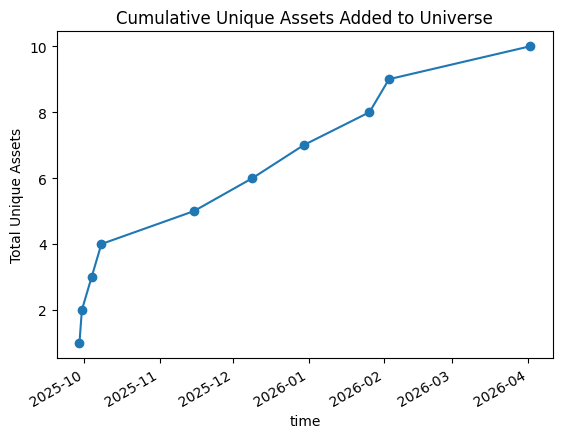

In [3]:
# Extract time and symbol arrays.
by_time = universe_history['time'].values if 'time' in universe_history.columns else universe_history.index.get_level_values(0)
by_symbol = universe_history['symbol'].values if 'symbol' in universe_history.columns else universe_history.index.get_level_values(1)
# Aggregate the raw per-contract rows into a single row per (time, symbol).
universe_history = universe_history.groupby([by_time, by_symbol]).agg(totalamount=('amount', 'sum'), contractcount=('amount', 'count'))
universe_history.index.names = ['time', 'symbol']
# Calculate and print universe metrics.
universe_size = universe_history.groupby(level='time').size()
print(f"Universe days: {len(universe_size)}")
print(f"Mean basket size per day: {universe_size.mean():.1f}")
factors = ['totalamount', 'contractcount']
for factor in factors:
    print(f'\n{universe_history[factor].describe().map("{:.3f}".format)}')
# Extract unique assets chronologically and calculate the cumulative growth.
unique_by_date = universe_history.reset_index().sort_values('time').drop_duplicates(subset=['symbol']).set_index('time')
unique_by_date['cumulative_count'] = range(1, len(unique_by_date) + 1)
unique_by_date['cumulative_count'].plot(
    title='Cumulative Unique Assets Added to Universe',
    ylabel='Total Unique Assets',
    marker='o'
);


### Daily Universe Prices

Fetch daily price history for every symbol that appears in the universe.

In [4]:
# Extract unique assets
symbols = list(universe_history.index.get_level_values(1).unique())
# Fetch daily historical price metrics using the earliest timestamp available in the index.
history = qb.history(symbols, universe_history.index[0][0] - timedelta(1), qb.time, Resolution.DAILY)
history

close     high      low   open      volume
symbol            time                                                  
TXG X7SGNKRL4WV9  2025-09-30  11.34  11.8857  11.2800  11.80   3774314.0
                  2025-10-01  11.69  11.7450  11.2300  11.39   2551389.0
                  2025-10-02  12.39  12.5300  11.6800  11.75   3070520.0
                  2025-10-03  12.31  12.5300  12.1700  12.46   2344431.0
                  2025-10-04  12.75  12.9650  12.3600  12.38   2419124.0
...                             ...      ...      ...    ...         ...
MDLN YYDBHHPS742T 2026-05-23  37.00  38.4000  36.9600  37.72  33977674.0
                  2026-05-27  36.14  37.2900  35.7100  37.00  13941196.0
                  2026-05-28  35.85  37.0200  35.6900  36.08   6687542.0
                  2026-05-29  36.81  36.8350  35.4401  35.85  12480142.0
                  2026-05-30  36.52  37.4750  36.4800  36.78   9421813.0

[1624 rows x 5 columns]

### Align Contract Volume And Returns

Build a joined table of factors and the future return.

In [ ]:
# Join the factor values with future returns and drop rows containing missing values.
dataset = universe_history[factors].join(history.open.unstack(0).pct_change().shift(-2).stack().rename('futurereturn').rename_axis(['time', 'symbol']), how='inner').dropna()
dataset.head()

,,totalamount,contractcount,futurereturn
time,symbol,,,
2025-09-30,BAH UROXQFIWOSX1,18487206.40,6,0.000401
2025-10-04,DNOW VR22RBI5MBFP,222382.01,214,-0.003153
2025-10-08,SYK R735QTJ8XC9X,450063.66,4,0.015616
2025-10-10,DNOW VR22RBI5MBFP,294421.70,299,-0.029392
2025-11-15,SENEA R735QTJ8XC9X,3194596.80,12,0.010146


### Analyze Relationships Between Factor and Future Returns

Create a grouped bar chart with standard error bars for each factor.

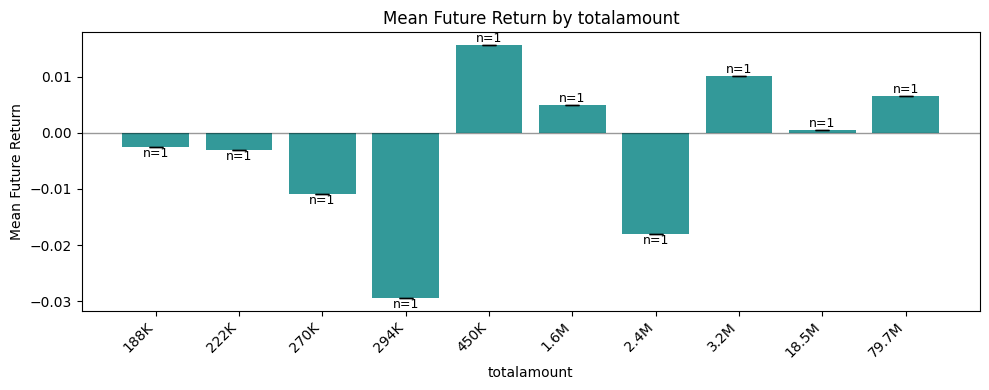

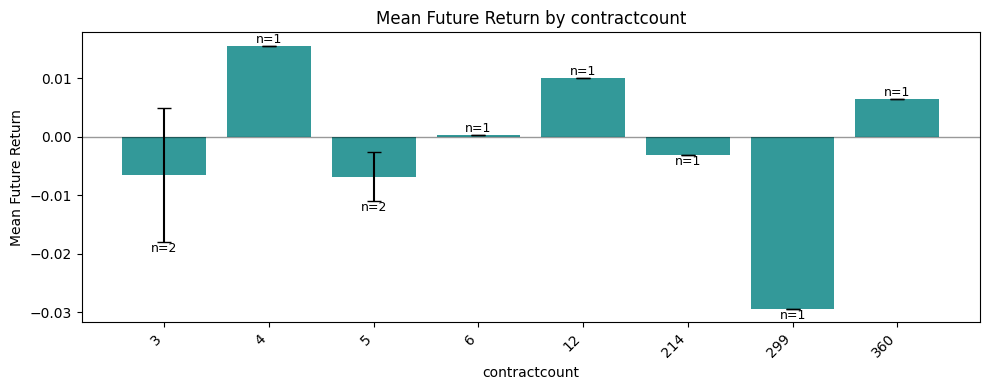

In [6]:
import matplotlib.ticker as mticker

for factor in factors:
    stats=dataset.groupby(factor)['futurereturn'].agg(['mean','sem','count']).reset_index()
    stats['sem']=stats['sem'].fillna(0.0)
    plt.figure(figsize=(10,4))
    # Format dollar amount into metric format.
    labels=stats[factor].apply(lambda x:f'{x/1e6:.1f}M' if x>=1e6 else f'{x/1e3:.0f}K') if factor=='totalamount' else stats[factor].astype(str)
    plt.bar(labels,stats['mean'],yerr=stats['sem'],color='teal',alpha=0.8,capsize=5)
    plt.axhline(0,color='black',linewidth=1,alpha=0.4)
    plt.title(f'Mean Future Return by {factor}')
    plt.xlabel(f'{factor}')
    plt.ylabel('Mean Future Return')
    plt.xticks(rotation=45,ha='right')
    # Annotate each bar with the number of observations in the group.
    for idx,row in stats.iterrows():
        y_pos=row['mean']+(row['sem'] if row['mean']>=0 else-row['sem'])
        v_align='bottom' if row['mean']>=0 else 'top'
        plt.text(idx,y_pos,f"n={int(row['count'])}",ha='center',va=v_align,fontsize=9)
    plt.tight_layout()
    plt.show()

Create a box plot of the contract volume quintiles compared to future returns.

In [ ]:
y = dataset.futurereturn
for factor in factors:
    # Split factor values into quantile buckets.
    x = dataset[factor]
    bucket_count = min(5, x.nunique())
    buckets = pd.qcut(x, q=bucket_count, duplicates='drop')
    # Summarize each bucket with distribution statistics.
    summary = dataset.assign(bucket=buckets).groupby('bucket', observed=True).agg(
        mean_factor=(factor, 'mean'),
        min_future_return=('futurereturn', 'min'),
        max_future_return=('futurereturn', 'max'),
        mean_future_return=('futurereturn', 'mean'),
        std_future_return=('futurereturn', 'std'),
        observations=('futurereturn', 'size')
    ).reset_index()
    summary['bucket'] = summary['bucket'].astype(str)
    # Display the bucket summary.
    print(f"Factor: {factor}")
    display(summary.style.format({
        'mean_factor': '{:.3f}',
        'min_future_return': '{:.2%}',
        'max_future_return': '{:.2%}',
        'mean_future_return': '{:.2%}',
        'std_future_return': '{:.2%}'
    }))
    # Plot the return distribution for each bucket.
    groups = [y[buckets == b].values for b in buckets.cat.categories]
    plt.boxplot(groups, labels=[str(b) for b in buckets.cat.categories])
    plt.axhline(0, color='black', linewidth=1, alpha=0.4)
    plt.title(f'Future Return by {factor} Bucket')
    plt.xlabel(f'{factor} Bucket')
    plt.ylabel('Future Return')
    plt.xticks(rotation=45)
    plt.show()

Factor: totalamount


,bucket,mean_factor,min_future_return,max_future_return,mean_future_return,std_future_return,observations
0,"(188082.499, 260876.402]",205232.255,-0.32%,-0.26%,-0.29%,0.04%,2
1,"(260876.402, 387806.876]",282460.850,-2.94%,-1.09%,-2.02%,1.31%,2
2,"(387806.876, 1898233.886]",1015965.335,0.50%,1.56%,1.03%,0.75%,2
3,"(1898233.886, 6253118.72]",2783690.500,-1.80%,1.01%,-0.39%,1.99%,2
4,"(6253118.72, 79653765.6]",49070486.000,0.04%,0.65%,0.35%,0.43%,2
